### Trajectory of Attitude Control Errors

Observed point-spread functions (PSFs) will suffer from attitude control errors. `jasmine_toolkit` provides a function to simulate a blurred PSF. The package has a class `Trajectory` that keeps a time sequence of attitude control errors.

In [1]:
import matplotlib
import matplotlib.pyplot as plt

from astropy.visualization import simple_norm
from jasmine_toolkit.optics.jitter import ACEModel, coeff_imagesim
from jasmine_toolkit.optics.trajectory import Trajectory
import numpy as np

matplotlib.rcParams['legend.frameon'] = False
matplotlib.rcParams['image.origin'] = 'lower'

Examples of attitude control error trajectories are illustrated below. We use `ACEModel` to generate two sequences.

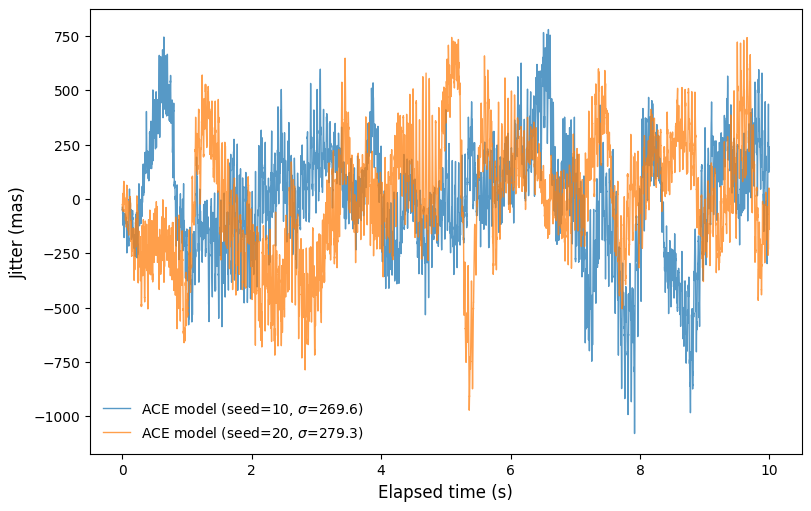

In [2]:
fig, ax = plt.subplots(
  figsize=(8, 5), layout='constrained')

N = 20000
sigma = 20.0
dt = 5e-4
latency = 100
gain = 0.00001

model = ACEModel(
  *coeff_imagesim(),
  sigma=sigma,
  sampling_interval=dt,
  latency=latency,
  gain=gain)

x = 1e3 * model.generate(N, seed=10)
y = 1e3 * model.generate(N, seed=20)

ax.plot(
  dt * np.arange(N), x, lw=1, alpha=0.75,
  label=f'ACE model (seed=10, $\sigma$={x.std():.1f})')
ax.plot(
  dt * np.arange(N), y, lw=1, alpha=0.75,
  label=f'ACE model (seed=20, $\sigma$={y.std():.1f})')

# ax.set_ylim([-28, 28])
ax.set_xlabel('Elapsed time (s)', fontsize=12)
ax.set_ylabel('Jitter (mas)', fontsize=12)
ax.legend(loc='lower left', fontsize=10)

plt.show()

We draw a trajectory on a focal plane in the cell below. The trajectory is converted into a (sub)pixel domain assuming that the pixel scale is 476 mas and the oversampling factor is 25.

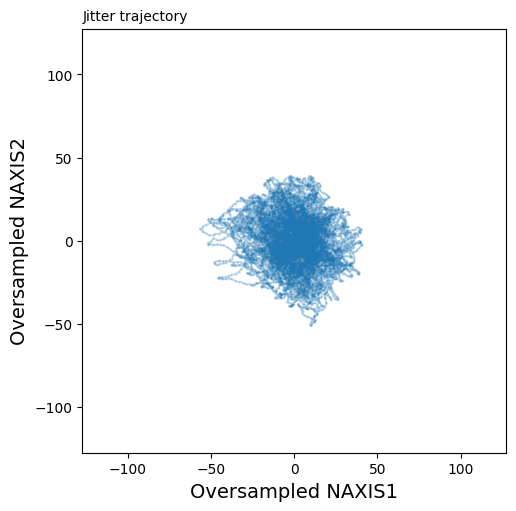

In [8]:
fig, ax = plt.subplots(
  figsize=(5.4, 5), layout='constrained')

pixel_scale = 476  # mas/pixel
oversample = 25  # oversampling factor

px = x / pixel_scale * oversample
py = y / pixel_scale * oversample

kernel = Trajectory(px, py, 255)

ax.plot(
  px, py, marker='.', markersize=1, alpha=0.25)
ax.set_xlim(kernel.extent[0:2])
ax.set_ylim(kernel.extent[2:4])
ax.set_aspect('equal')
ax.set_xlabel('Oversampled NAXIS1', fontsize=14)
ax.set_ylabel('Oversampled NAXIS2', fontsize=14)
ax.set_title('Jitter trajectory', loc='left', fontsize=10)

plt.show()

How a PSF is affected is illustrated below. The left panel shows an oversampled original PSF, which is given by a Gaussian function. The middle panel shows a convolution kernel generated from the jitter trajectory. A blurred PSF, provided by a convolution of the original PSF and the kernel, is displayed in the right panel. The size of the convolution kernel is set to the same as the original PSF just for simplicity. In case that jitter amplitudes are smaller than a PSF, we can use a smaller kernel to reduce the computational cost.

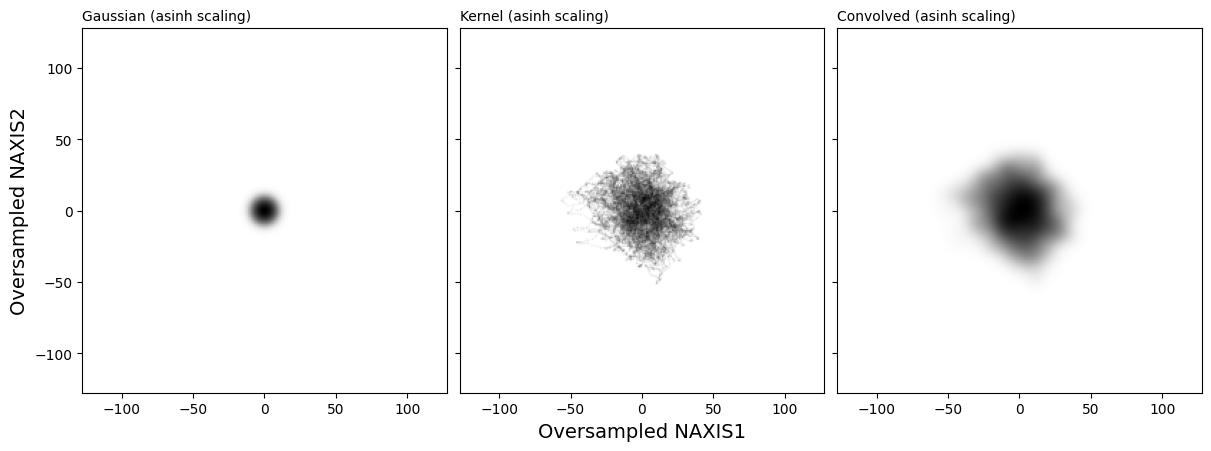

In [9]:
fig, axes = plt.subplots(
  1, 3, figsize=(12, 4.2), sharey=True, layout='constrained')

ay, ax = np.mgrid[-127:128, -127:128]
canvas = np.exp(-(ax**2 + ay**2) / 2 / 5**2)

norm = simple_norm(canvas, 'asinh')
axes[0].imshow(
  canvas, norm=norm,
  cmap='gray_r', extent=kernel.extent)
axes[0].set_aspect('equal')
axes[0].set_title(
  'Gaussian (asinh scaling)', loc='left', fontsize=10)

norm = simple_norm(kernel.canvas, 'asinh')
axes[1].imshow(
  kernel.canvas, norm=norm,
  cmap='gray_r', extent=kernel.extent)
axes[1].set_aspect('equal')
axes[1].set_title(
  'Kernel (asinh scaling)', loc='left', fontsize=10)

norm = simple_norm(kernel.convolve(canvas), 'asinh')
axes[2].imshow(
  kernel.convolve(canvas), norm=norm,
  cmap='gray_r', extent=kernel.extent)
axes[2].set_aspect('equal')
axes[2].set_title(
  'Convolved (asinh scaling)', loc='left', fontsize=10)

axes[1].set_xlabel('Oversampled NAXIS1', fontsize=14)
axes[0].set_ylabel('Oversampled NAXIS2', fontsize=14)

plt.show()